In [1]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import sklearn
from sklearn.preprocessing import StandardScaler

In [2]:
#importing csv data

leads = pd.read_csv("D:/Downloads/Leads.csv")

#Returns first few rows

leads.head()


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [3]:
#shape of the data
leads.shape

(9240, 37)

In [4]:
# here the data ha 9240 rows and 37 columns

In [5]:
#structure of the data
leads.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [6]:
# Summary for numeric columns
leads.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [7]:
#check the duplicates
duplicate_prospect_ID = sum(leads.duplicated(subset='Prospect ID')) == 0

duplicate_prospect_ID

True

In [8]:
duplicate_Lead_Number = sum(leads.duplicated(subset='Lead Number')) == 0

duplicate_Lead_Number

True

In [9]:
#EDA starts from here
# dropping the "Prospect ID" and "Lead Number", since there is no null values 
# if we observe the data set we have some cells filled with "Select". so we can replace with Nan 

In [10]:
leads.drop(['Prospect ID', 'Lead Number'], axis=1, inplace = True)

In [11]:
leads = leads.replace('Select', np.nan)

In [12]:
leads.head(1)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,...,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Modified


In [13]:
#finding the percentage of null values
per_missing_data = 100*(leads.isnull().sum()/len(leads.index))
per_missing_data

Lead Origin                                       0.000000
Lead Source                                       0.389610
Do Not Email                                      0.000000
Do Not Call                                       0.000000
Converted                                         0.000000
TotalVisits                                       1.482684
Total Time Spent on Website                       0.000000
Page Views Per Visit                              1.482684
Last Activity                                     1.114719
Country                                          26.634199
Specialization                                   36.580087
How did you hear about X Education               78.463203
What is your current occupation                  29.112554
What matters most to you in choosing a course    29.318182
Search                                            0.000000
Magazine                                          0.000000
Newspaper Article                                 0.0000

In [14]:
#seeing the above 45% of null values
print(per_missing_data[per_missing_data > 45])

How did you hear about X Education    78.463203
Lead Quality                          51.590909
Lead Profile                          74.188312
Asymmetrique Activity Index           45.649351
Asymmetrique Profile Index            45.649351
Asymmetrique Activity Score           45.649351
Asymmetrique Profile Score            45.649351
dtype: float64


In [15]:
#dropping the all the null value columns above 45%
leads = leads.drop(columns=per_missing_data[per_missing_data > 45].index)


In [16]:
leads.shape

(9240, 28)

In [17]:
# Categorical Attributes Analysis 

In [18]:
100*(leads.isnull().sum()/len(leads.index))

Lead Origin                                       0.000000
Lead Source                                       0.389610
Do Not Email                                      0.000000
Do Not Call                                       0.000000
Converted                                         0.000000
TotalVisits                                       1.482684
Total Time Spent on Website                       0.000000
Page Views Per Visit                              1.482684
Last Activity                                     1.114719
Country                                          26.634199
Specialization                                   36.580087
What is your current occupation                  29.112554
What matters most to you in choosing a course    29.318182
Search                                            0.000000
Magazine                                          0.000000
Newspaper Article                                 0.000000
X Education Forums                                0.0000

In [19]:
# checking the value counts of the Lead Source
leads['Lead Source'].value_counts(dropna=False)

Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
NaN                    36
bing                    6
google                  5
Click2call              4
Press_Release           2
Social Media            2
Live Chat               2
youtubechannel          1
testone                 1
Pay per Click Ads       1
welearnblog_Home        1
WeLearn                 1
blog                    1
NC_EDM                  1
Name: count, dtype: int64

In [20]:
# here google has 2 attributes, changing to one and at the same time low frequency values changing to others
leads['Lead Source'] = leads['Lead Source'].replace('google', 'Google')
leads['Lead Source'] = leads['Lead Source'].replace(np.nan, 'Others')
leads['Lead Source'] = leads['Lead Source'].replace(['bing','Click2call','Press_Release','Social Media','Live Chat','youtubechannel','testone',
                                                     'Pay per Click Ads','welearnblog_Home','WeLearn','blog','NC_EDM'],'Others')

In [21]:
leads['Lead Source'].value_counts(dropna=False)

Lead Source
Google              2873
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Others                59
Facebook              55
Name: count, dtype: int64

In [22]:
leads['Lead Source'] = leads['Lead Source'].replace('Othres','Others')

In [23]:
leads['Lead Source'].value_counts(dropna=False)

Lead Source
Google              2873
Direct Traffic      2543
Olark Chat          1755
Organic Search      1154
Reference            534
Welingak Website     142
Referral Sites       125
Others                59
Facebook              55
Name: count, dtype: int64

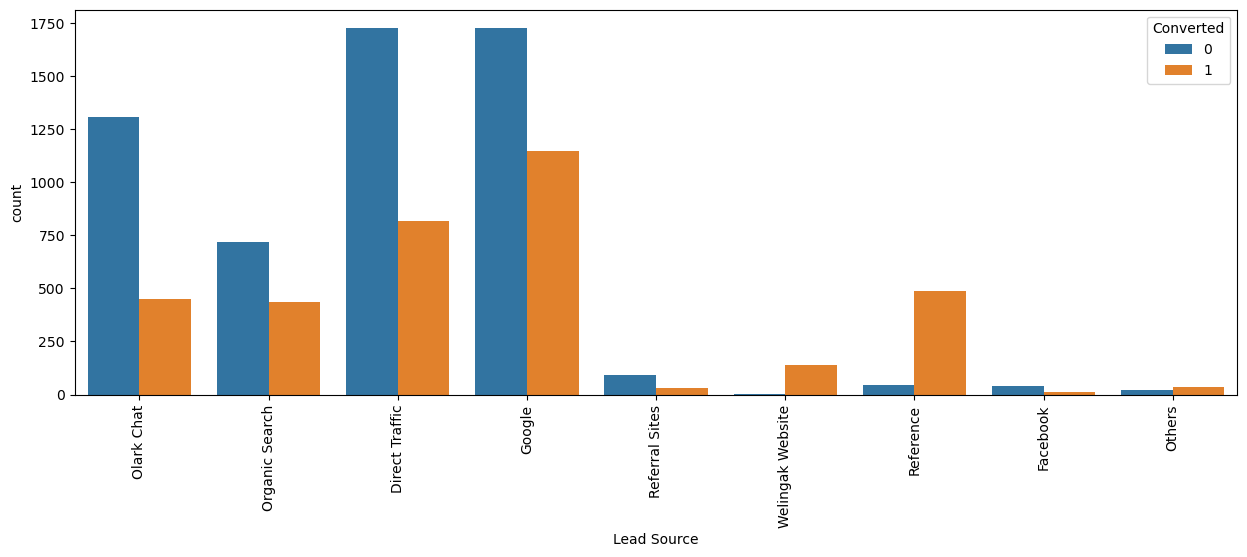

In [24]:
#visualizing  on Lead Source and count
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='Lead Source', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [25]:
leads['TotalVisits'].dtype

dtype('float64')

In [26]:
leads['TotalVisits'].dtype

dtype('float64')

In [27]:
leads['Last Activity'].dtype

dtype('O')

In [28]:
# checking the value counts of the Last Activity
leads['Last Activity'].value_counts(dropna=False)

Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
NaN                              103
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: count, dtype: int64

In [29]:
# same as above we cleaning the above one do the samr here Last Activity
leads['Last Activity'] = leads['Last Activity'].replace(np.nan, 'Others')
leads['Last Activity'] = leads['Last Activity'].replace(['Unreachable','Unsubscribed','Had a Phone Conversation','Approached upfront','View in browser link Clicked',
                                                     'Email Received','Email Marked Spam','Visited Booth in Tradeshow','Resubscribed to emails'],'Others')

In [30]:
leads['Last Activity'].value_counts(dropna=False)

Last Activity
Email Opened                 3437
SMS Sent                     2745
Olark Chat Conversation       973
Page Visited on Website       640
Converted to Lead             428
Email Bounced                 326
Others                        308
Email Link Clicked            267
Form Submitted on Website     116
Name: count, dtype: int64

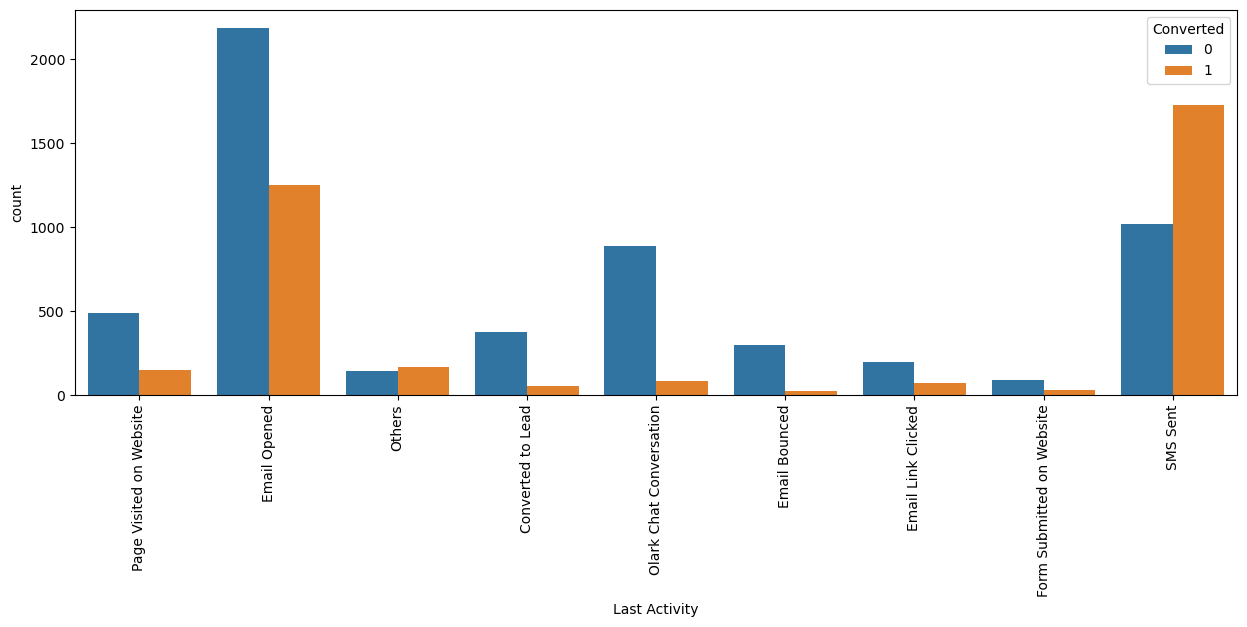

In [31]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='Last Activity', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [32]:
# checking the value counts of the Country
leads['Country'].value_counts(dropna=False)

Country
India                   6492
NaN                     2461
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Bahrain                    7
Hong Kong                  7
Oman                       6
France                     6
unknown                    5
Kuwait                     4
South Africa               4
Canada                     4
Nigeria                    4
Germany                    4
Sweden                     3
Philippines                2
Uganda                     2
Italy                      2
Bangladesh                 2
Netherlands                2
Asia/Pacific Region        2
China                      2
Belgium                    2
Ghana                      2
Kenya                      1
Sri Lanka                  1
Tanzania                   1
Malaysia                   1
Liberia                    1
Switze

In [33]:
leads['Country'] = leads['Country'].replace(np.nan, 'India')

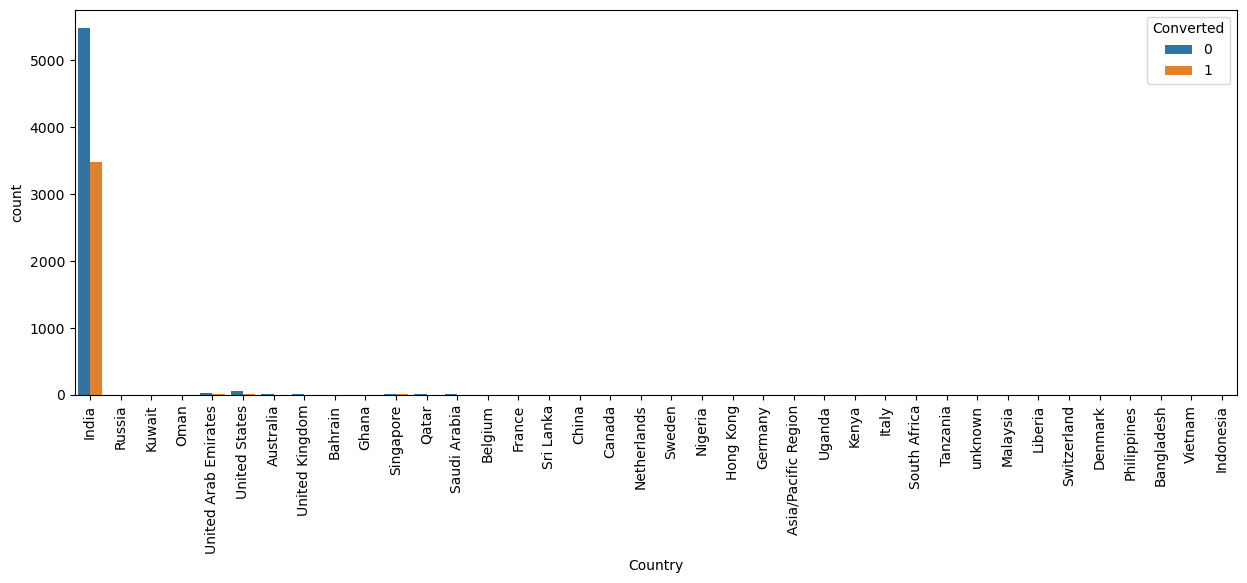

In [34]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='Country', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [35]:
# here the 90% above is India so we can drop the column 
leads.drop('Country', axis = 1, inplace = True)


In [36]:
leads.columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Specialization',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [37]:
# checking the value counts of the Specialization
leads['Specialization'].value_counts(dropna=False)

Specialization
NaN                                  3380
Finance Management                    976
Human Resource Management             848
Marketing Management                  838
Operations Management                 503
Business Administration               403
IT Projects Management                366
Supply Chain Management               349
Banking, Investment And Insurance     338
Travel and Tourism                    203
Media and Advertising                 203
International Business                178
Healthcare Management                 159
Hospitality Management                114
E-COMMERCE                            112
Retail Management                     100
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

In [38]:
leads['Specialization'] = leads['Specialization'].replace(['Finance Management','Human Resource Management',
                                                           'Marketing Management','Operations Management',
                                                           'IT Projects Management','Supply Chain Management',
                                                    'Healthcare Management','Hospitality Management',
                                                           'Retail Management'] ,'Management_Specializations')  

In [39]:
leads['Specialization'] = leads['Specialization'].replace(np.nan ,'Not_Mentioned')  

In [40]:
leads['Specialization'].value_counts(dropna=False)

Specialization
Management_Specializations           4253
Not_Mentioned                        3380
Business Administration               403
Banking, Investment And Insurance     338
Media and Advertising                 203
Travel and Tourism                    203
International Business                178
E-COMMERCE                            112
Rural and Agribusiness                 73
E-Business                             57
Services Excellence                    40
Name: count, dtype: int64

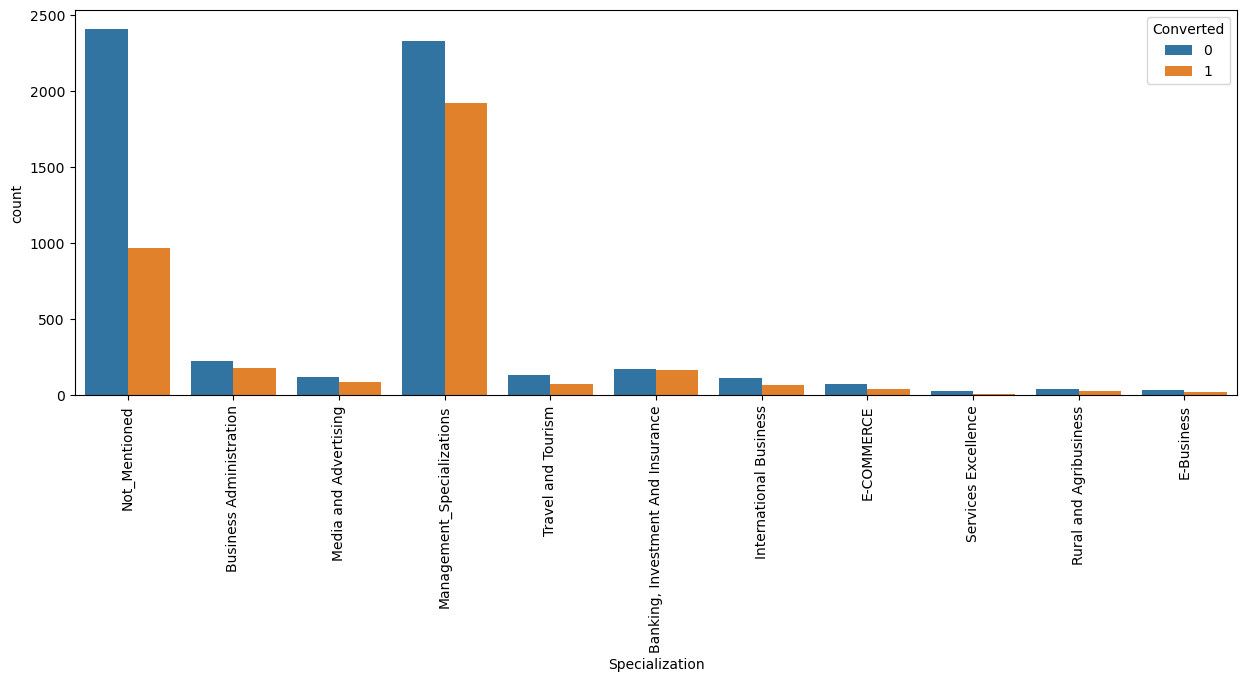

In [41]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='Specialization', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [42]:
# checking the value counts of the What is your current occupation
leads['What is your current occupation'].value_counts(dropna=False)

What is your current occupation
Unemployed              5600
NaN                     2690
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

In [43]:
leads['What is your current occupation'] = leads['What is your current occupation'].replace(np.nan, 'Unemployed')

In [44]:
leads['What is your current occupation'].value_counts(dropna=False)

What is your current occupation
Unemployed              8290
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

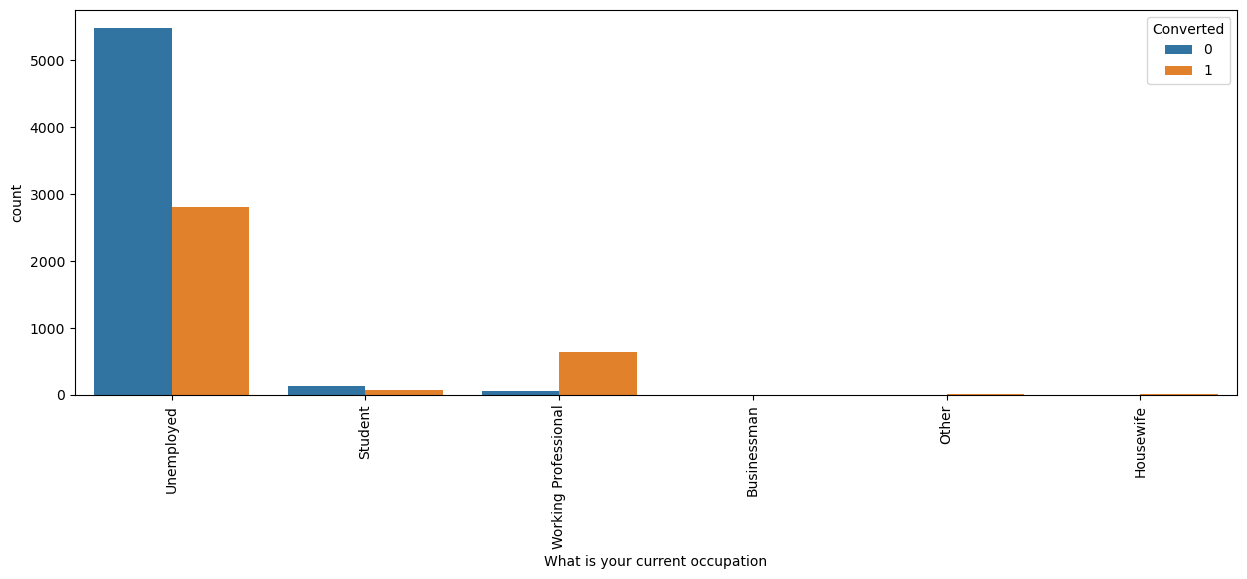

In [45]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='What is your current occupation', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [46]:
# checking the value counts of the What matters most to you in choosing a course
leads['What matters most to you in choosing a course'].value_counts(dropna=False)

What matters most to you in choosing a course
Better Career Prospects      6528
NaN                          2709
Flexibility & Convenience       2
Other                           1
Name: count, dtype: int64

In [47]:
#replacing Nan values with Mode "Better Career Prospects"

leads['What matters most to you in choosing a course'] = leads['What matters most to you in choosing a course'].replace(np.nan,'Better Career Prospects')

In [48]:
leads['What matters most to you in choosing a course'].value_counts(dropna=False)

What matters most to you in choosing a course
Better Career Prospects      9237
Flexibility & Convenience       2
Other                           1
Name: count, dtype: int64

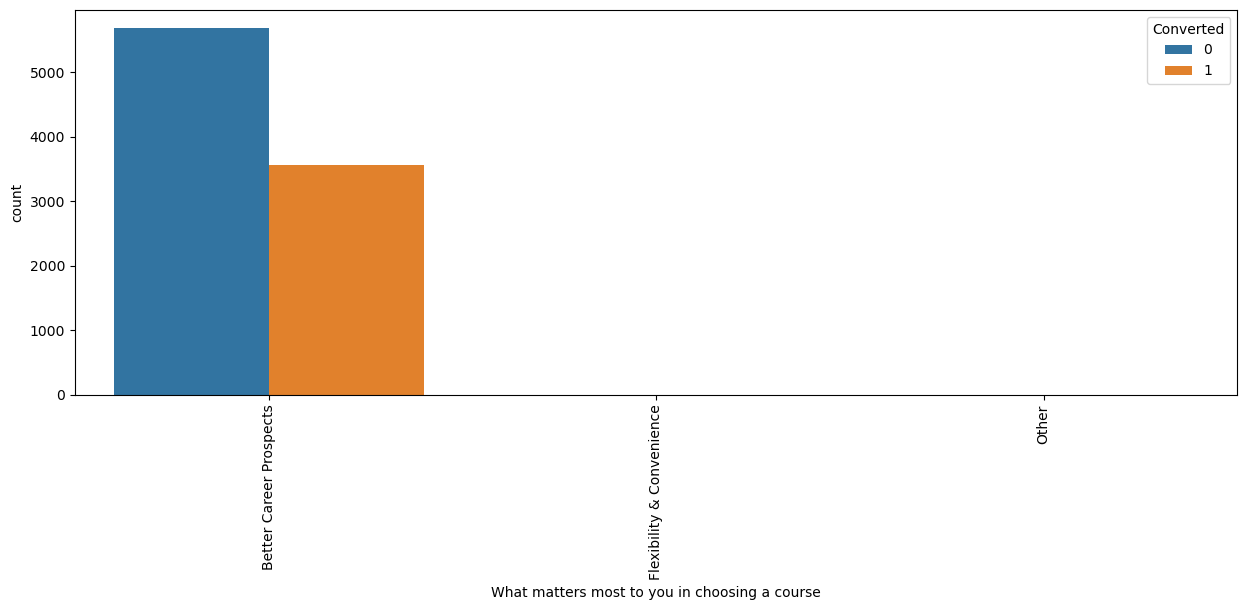

In [49]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='What matters most to you in choosing a course', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [50]:
# here the 90% above in What matters most to you in choosing a course is 'Better career prospects' so we can drop the column 
leads.drop('What matters most to you in choosing a course', axis = 1, inplace = True)

In [51]:
leads.columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Specialization',
       'What is your current occupation', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [52]:
# checking the value counts of the Tags
leads['Tags'].value_counts(dropna=False)

Tags
NaN                                                  3353
Will revert after reading the email                  2072
Ringing                                              1203
Interested in other courses                           513
Already a student                                     465
Closed by Horizzon                                    358
switched off                                          240
Busy                                                  186
Lost to EINS                                          175
Not doing further education                           145
Interested  in full time MBA                          117
Graduation in progress                                111
invalid number                                         83
Diploma holder (Not Eligible)                          63
wrong number given                                     47
opp hangup                                             33
number not provided                                    27
in touch 

In [53]:
leads['Tags'] = leads['Tags'].replace(np.nan, 'Not_mentioned')
leads['Tags'] = leads['Tags'].replace(['invalid number','Diploma holder (Not Eligible)','wrong number given',
                                                        'opp hangup','number not provided','in touch with EINS','Lost to Others',
                                                        'Still Thinking','Want to take admission but has financial problems',
                                                        'In confusion whether part time or DLP','Interested in Next batch','Lateral student',
                                                        'Shall take in the next coming month','University not recognized',
                                                        'Recognition issue (DEC approval)'], 'Other')

In [54]:
leads['Tags'].value_counts(dropna=False)

Tags
Not_mentioned                          3353
Will revert after reading the email    2072
Ringing                                1203
Interested in other courses             513
Already a student                       465
Closed by Horizzon                      358
Other                                   302
switched off                            240
Busy                                    186
Lost to EINS                            175
Not doing further education             145
Interested  in full time MBA            117
Graduation in progress                  111
Name: count, dtype: int64

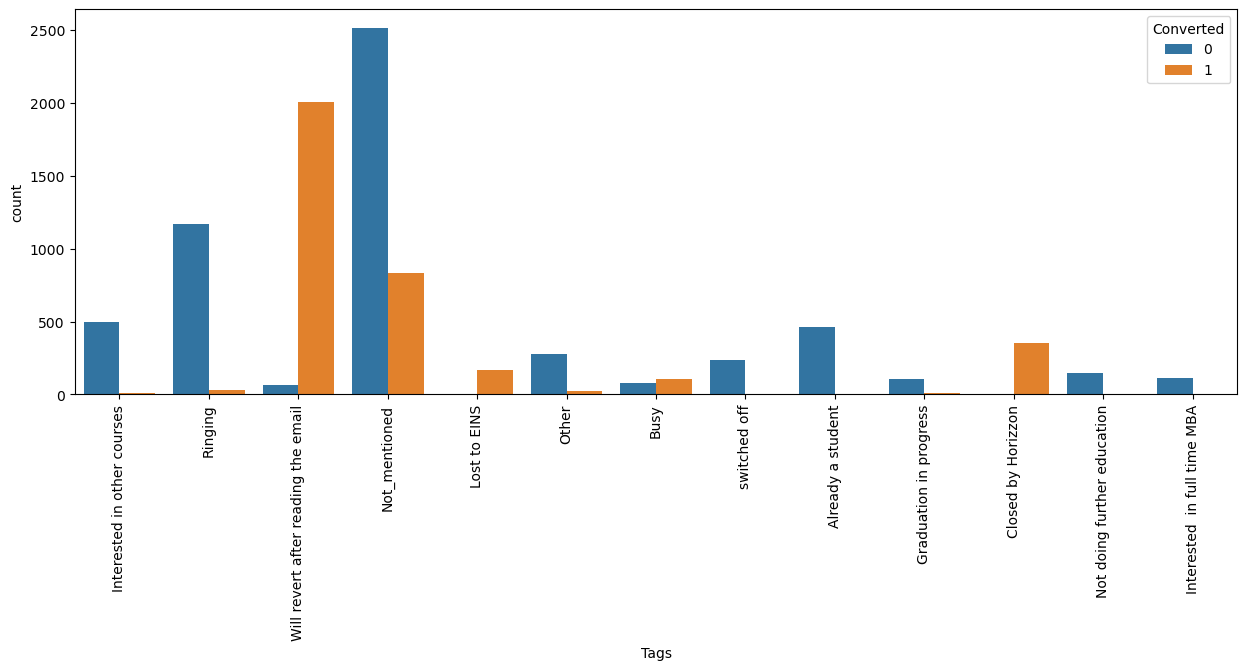

In [55]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='Tags', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [56]:
# checking the value counts of the Tags
leads['City'].value_counts(dropna=False)

City
NaN                            3669
Mumbai                         3222
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: count, dtype: int64

In [57]:
leads['City'] = leads['City'].replace(np.nan,'Mumbai')

In [58]:
leads['City'].value_counts(dropna=False)

City
Mumbai                         6891
Thane & Outskirts               752
Other Cities                    686
Other Cities of Maharashtra     457
Other Metro Cities              380
Tier II Cities                   74
Name: count, dtype: int64

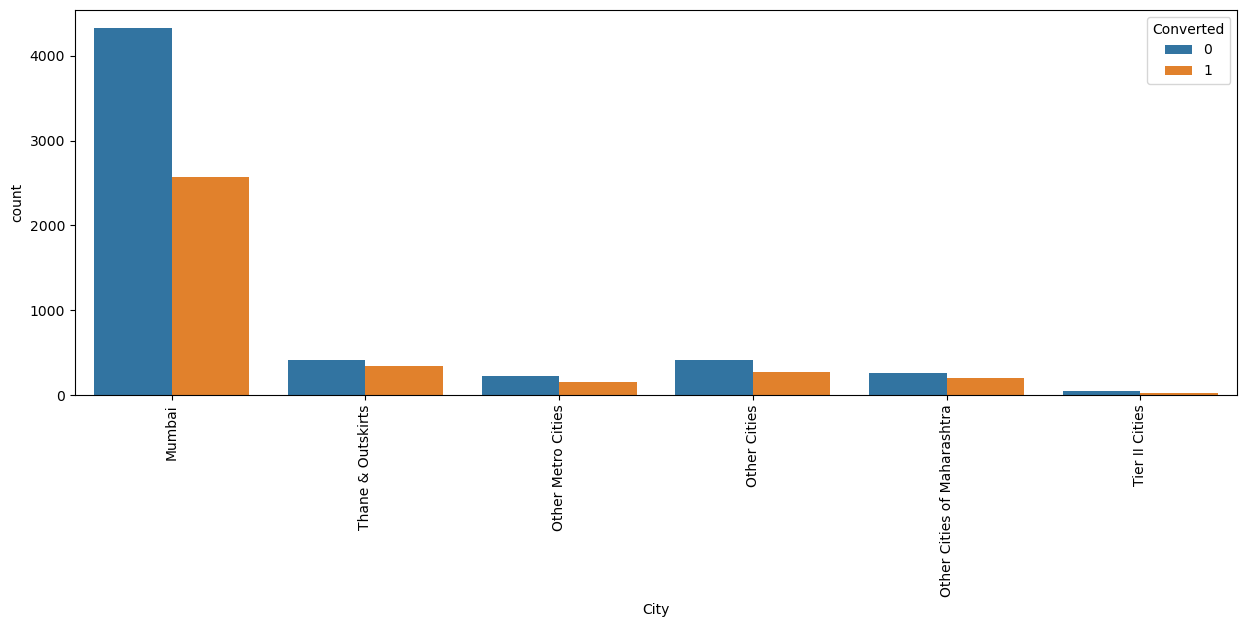

In [59]:
plt.figure(figsize = (15,5))
s1 = sns.countplot(data=leads, x='City', hue='Converted')
s1.set_xticklabels(s1.get_xticklabels(), rotation=90)
plt.show()

In [60]:
#now checking the null values 
100*(leads.isnull().sum()/len(leads.index))

Lead Origin                                 0.000000
Lead Source                                 0.000000
Do Not Email                                0.000000
Do Not Call                                 0.000000
Converted                                   0.000000
TotalVisits                                 1.482684
Total Time Spent on Website                 0.000000
Page Views Per Visit                        1.482684
Last Activity                               0.000000
Specialization                              0.000000
What is your current occupation             0.000000
Search                                      0.000000
Magazine                                    0.000000
Newspaper Article                           0.000000
X Education Forums                          0.000000
Newspaper                                   0.000000
Digital Advertisement                       0.000000
Through Recommendations                     0.000000
Receive More Updates About Our Courses      0.

In [61]:
# here we have only 'TotalVisits' & 'Page Views Per Visit' are below 2% so we can drop the null values,
#2% values does not effect the data

leads = leads.dropna()

In [62]:
#check again  null values once ifit is go for good
100*(leads.isnull().sum()/len(leads.index))

Lead Origin                                 0.0
Lead Source                                 0.0
Do Not Email                                0.0
Do Not Call                                 0.0
Converted                                   0.0
TotalVisits                                 0.0
Total Time Spent on Website                 0.0
Page Views Per Visit                        0.0
Last Activity                               0.0
Specialization                              0.0
What is your current occupation             0.0
Search                                      0.0
Magazine                                    0.0
Newspaper Article                           0.0
X Education Forums                          0.0
Newspaper                                   0.0
Digital Advertisement                       0.0
Through Recommendations                     0.0
Receive More Updates About Our Courses      0.0
Tags                                        0.0
Update me on Supply Chain Content       

In [63]:
leads.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9103 entries, 0 to 9239
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Lead Origin                               9103 non-null   object 
 1   Lead Source                               9103 non-null   object 
 2   Do Not Email                              9103 non-null   object 
 3   Do Not Call                               9103 non-null   object 
 4   Converted                                 9103 non-null   int64  
 5   TotalVisits                               9103 non-null   float64
 6   Total Time Spent on Website               9103 non-null   int64  
 7   Page Views Per Visit                      9103 non-null   float64
 8   Last Activity                             9103 non-null   object 
 9   Specialization                            9103 non-null   object 
 10  What is your current occupation          

In [64]:
#Check the % of Data that has Converted Values = 1:

Converted = (sum(leads['Converted'])/len(leads['Converted'].index))*100
Converted

38.02043282434362

In [65]:
numeric_leads = leads.select_dtypes(include=['int64', 'float64'])
numeric_leads.head()

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
0,0,0.0,0,0.0
1,0,5.0,674,2.5
2,1,2.0,1532,2.0
3,0,1.0,305,1.0
4,1,2.0,1428,1.0


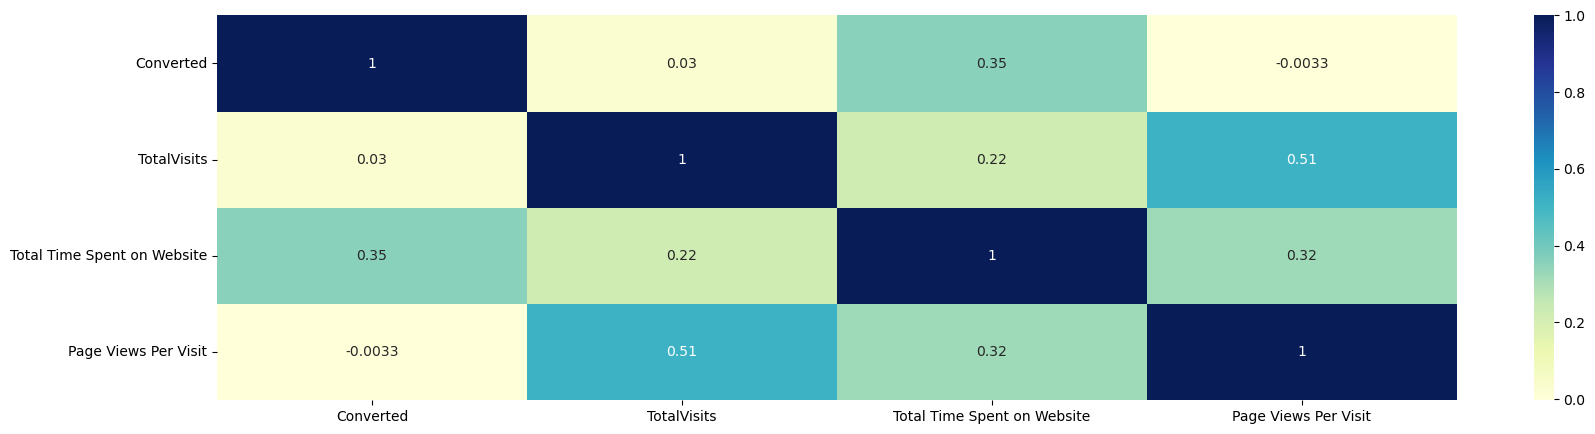

In [66]:
plt.figure(figsize=(20,5))

# heatmap
sns.heatmap(numeric_leads.corr(), cmap="YlGnBu", annot=True)
plt.show()

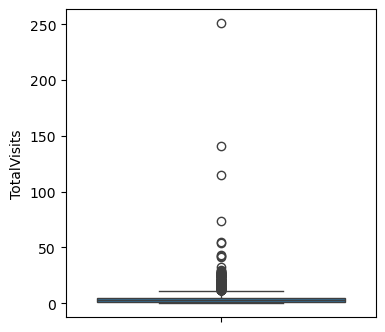

In [67]:
#lets check the outliers 
# checking for TotalVisits
plt.figure(figsize=(4,4))
sns.boxplot(y=leads['TotalVisits'])
plt.show()

In [68]:
leads['TotalVisits'].describe(percentiles=[0.05,.25, .5, .75, .90, .95, .99])

count    9103.000000
mean        3.445238
std         4.854853
min         0.000000
5%          0.000000
25%         1.000000
50%         3.000000
75%         5.000000
90%         7.000000
95%        10.000000
99%        17.000000
max       251.000000
Name: TotalVisits, dtype: float64

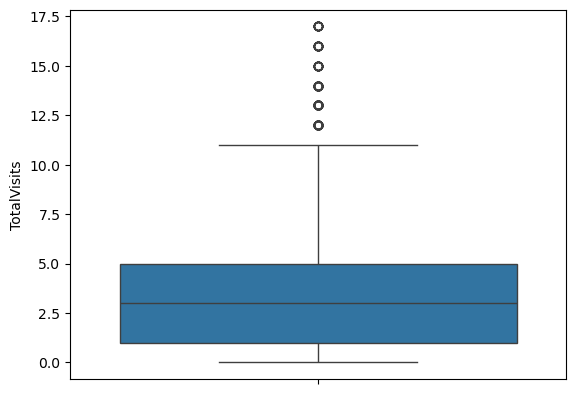

In [69]:
#Outlier : Remove top & bottom 1% 
Q3 = leads.TotalVisits.quantile(0.99)
leads = leads[(leads.TotalVisits <= Q3)]
Q1 = leads.TotalVisits.quantile(0.01)
leads = leads[(leads.TotalVisits >= Q1)]
sns.boxplot(y=leads['TotalVisits'])
plt.show()


In [70]:
leads.shape

(9020, 26)

In [71]:
#checking percentiles for "Total Time Spent on Website"

leads['Total Time Spent on Website'].describe(percentiles=[0.05,.25, .5, .75, .90, .95, .99])

count    9020.000000
mean      479.759534
std       544.688157
min         0.000000
5%          0.000000
25%         7.000000
50%       243.000000
75%       915.250000
90%      1371.000000
95%      1554.050000
99%      1836.620000
max      2272.000000
Name: Total Time Spent on Website, dtype: float64

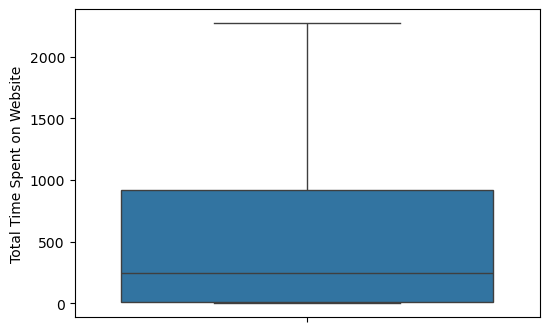

In [72]:
#lets check the outliers Total Time Spent on Website
plt.figure(figsize=(6,4))
sns.boxplot(y=leads['Total Time Spent on Website'])
plt.show()

In [73]:
#checking  of "Page Views Per Visit"

leads['Page Views Per Visit'].describe()

count    9020.000000
mean        2.337271
std         2.062363
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        16.000000
Name: Page Views Per Visit, dtype: float64

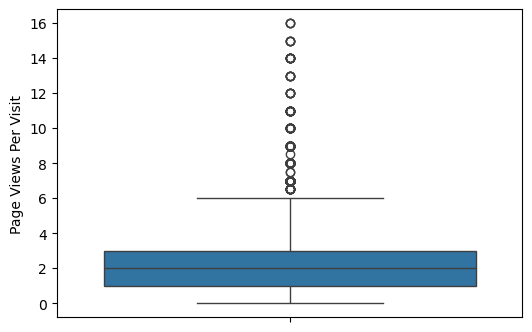

In [74]:
#visualizing Page Views Per Visit of numeric variable

plt.figure(figsize=(6,4))
sns.boxplot(y=leads['Page Views Per Visit'])
plt.show()

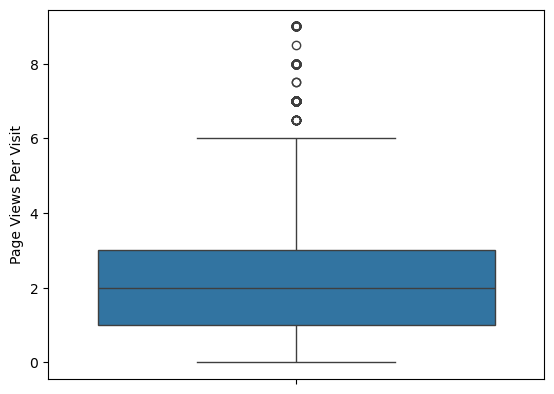

In [75]:
#Outlier : Remove top & bottom 1% 

Q3 = leads['Page Views Per Visit'].quantile(0.99)
leads = leads[leads['Page Views Per Visit'] <= Q3]
Q1 = leads['Page Views Per Visit'].quantile(0.01)
leads = leads[leads['Page Views Per Visit'] >= Q1]
sns.boxplot(y=leads['Page Views Per Visit'])
plt.show()

In [76]:
leads.shape

(8953, 26)

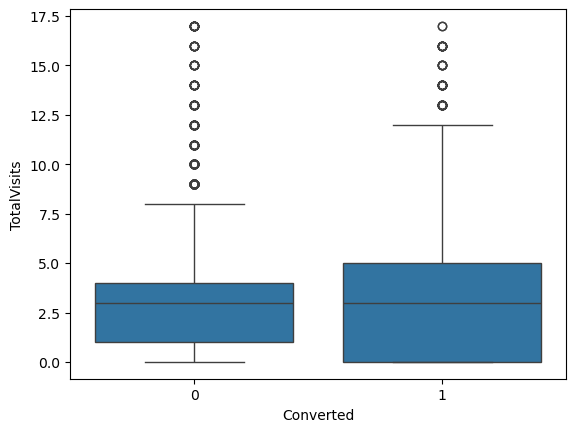

In [77]:
#checking "Total Visits" vs Converted variable
sns.boxplot(y = 'TotalVisits', x = 'Converted', data = leads)
plt.show()

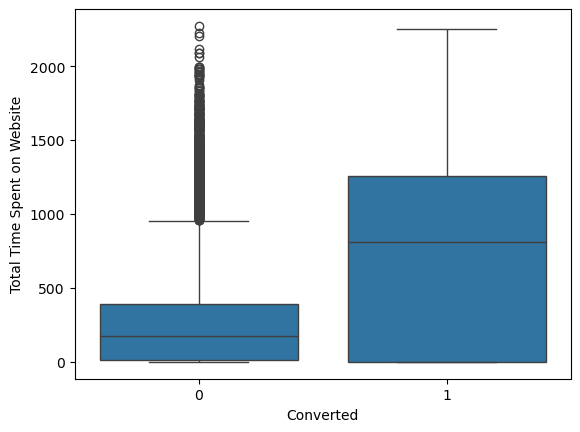

In [78]:
#checking  "Total Time Spent on Website" vs Converted variable

sns.boxplot(x=leads.Converted, y=leads['Total Time Spent on Website'])
plt.show()

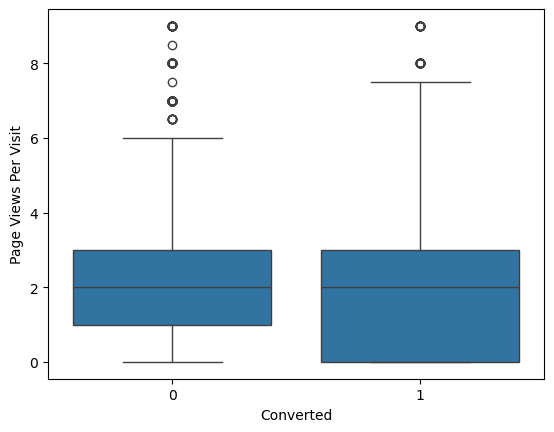

In [79]:
#checking  "Page Views Per Visit" vs Converted variable

sns.boxplot(x=leads.Converted,y=leads['Page Views Per Visit'])
plt.show()

In [80]:
# Dummy Variable Creation:

In [81]:
obj_cols= leads.select_dtypes(include=['object']).columns
obj_cols

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Last Activity', 'Specialization', 'What is your current occupation',
       'Search', 'Magazine', 'Newspaper Article', 'X Education Forums',
       'Newspaper', 'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [82]:
yes_no_cols = leads.columns[leads.isin(['Yes', 'No']).all()]
yes_no_cols

Index(['Do Not Email', 'Do Not Call', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview'],
      dtype='object')

In [83]:
# List of variables to map

varlist =  ['Do Not Email', 'Do Not Call', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview']

# Defining the map function
def binary_map(x):
    return x.map({'Yes': 1, "No": 0})

# Applying the function to the housing list
leads[varlist] = leads[varlist].apply(binary_map)

In [84]:
objects = leads.select_dtypes(include='object').loc[:, ~leads.isin(['Yes', 'No']).all()]
objects.head()

,Lead Origin,Lead Source,Last Activity,Specialization,What is your current occupation,Tags,City,Last Notable Activity
0,API,Olark Chat,Page Visited on Website,Not_Mentioned,Unemployed,Interested in other courses,Mumbai,Modified
1,API,Organic Search,Email Opened,Not_Mentioned,Unemployed,Ringing,Mumbai,Email Opened
2,Landing Page Submission,Direct Traffic,Email Opened,Business Administration,Student,Will revert after reading the email,Mumbai,Email Opened
3,Landing Page Submission,Direct Traffic,Others,Media and Advertising,Unemployed,Ringing,Mumbai,Modified
4,Landing Page Submission,Google,Converted to Lead,Not_Mentioned,Unemployed,Will revert after reading the email,Mumbai,Modified


In [85]:
#getting dummies and dropping the first column and adding the results to the master dataframe


dummy = pd.get_dummies(leads[['Lead Origin','What is your current occupation',
                             'City']], drop_first=True)
dummy = dummy.astype(int)
leads = pd.concat([leads, dummy], axis=1)


In [86]:
dummy = pd.get_dummies(leads['Specialization'], prefix  = 'Specialization')
dummy = dummy.astype(int)
dummy = dummy.drop(['Specialization_Not_Mentioned'], axis = 1)
leads = pd.concat([leads, dummy], axis = 1)

In [87]:
dummy = pd.get_dummies(leads['Lead Source'], prefix  = 'Lead Source')
dummy = dummy.astype(int)
dummy = dummy.drop(['Lead Source_Others'],  axis = 1)
leads = pd.concat([leads, dummy], axis = 1)

In [88]:
dummy = pd.get_dummies(leads['Last Activity'], prefix  = 'Last Activity')
dummy = dummy.astype(int)
dummy = dummy.drop(['Last Activity_Others'], axis=1)
leads = pd.concat([leads, dummy], axis = 1)

In [89]:
dummy = pd.get_dummies(leads['Tags'], prefix  = 'Tags')
dummy = dummy.astype(int)
dummy = dummy.drop(['Tags_Not_mentioned'], axis=1)
leads = pd.concat([leads, dummy], axis = 1)

In [90]:
dummy = pd.get_dummies(leads['Last Notable Activity'], prefix='Last Notable Activity')
dummy = dummy.astype(int)
dummy = dummy.drop(['Last Notable Activity_Other Notable Activity'], axis=1, errors='ignore')
leads = pd.concat([leads, dummy], axis=1)

In [91]:
#dropping the original columns after dummy variable creation

leads.drop(obj_cols,axis=1,inplace = True)

In [92]:
leads.head()

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,0,0.0,0,0.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,5.0,674,2.5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2.0,1532,2.0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,1.0,305,1.0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,1,2.0,1428,1.0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [93]:
#Train-Test Split & Logistic Regression Model Building:
from sklearn.model_selection import train_test_split

# Putting response variable to y
y = leads['Converted']

y.head()

X=leads.drop('Converted', axis=1)

In [94]:
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [95]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6267 entries, 9196 to 5825
Data columns (total 70 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   TotalVisits                                           6267 non-null   float64
 1   Total Time Spent on Website                           6267 non-null   int64  
 2   Page Views Per Visit                                  6267 non-null   float64
 3   Lead Origin_Landing Page Submission                   6267 non-null   int32  
 4   Lead Origin_Lead Add Form                             6267 non-null   int32  
 5   Lead Origin_Lead Import                               6267 non-null   int32  
 6   What is your current occupation_Housewife             6267 non-null   int32  
 7   What is your current occupation_Other                 6267 non-null   int32  
 8   What is your current occupation_Student               6267 n

In [96]:
#scaling numeric columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols=X_train.select_dtypes(include=['float64', 'int64']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_train.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
9196,0.668862,1.848117,1.455819,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
4696,-0.030697,-0.037832,0.399961,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3274,0.319082,-0.642138,-0.127967,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2164,-0.380477,-0.154676,-0.127967,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1667,0.319082,1.258415,-0.481679,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [97]:
import statsmodels.api as sm

In [98]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()

from sklearn.feature_selection import RFE
rfe = RFE(estimator=logreg, n_features_to_select=15)          # running RFE with 15 variables as output
rfe = rfe.fit(X_train, y_train)

In [99]:
rfe.support_

array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False,  True,  True, False,  True,
       False, False,  True,  True,  True,  True,  True,  True,  True,
       False, False,  True, False, False, False, False, False,  True,
        True, False, False, False, False, False, False])

In [100]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('TotalVisits', False, 31),
 ('Total Time Spent on Website', False, 3),
 ('Page Views Per Visit', False, 30),
 ('Lead Origin_Landing Page Submission', False, 15),
 ('Lead Origin_Lead Add Form', True, 1),
 ('Lead Origin_Lead Import', False, 37),
 ('What is your current occupation_Housewife', False, 39),
 ('What is your current occupation_Other', False, 27),
 ('What is your current occupation_Student', False, 29),
 ('What is your current occupation_Unemployed', False, 28),
 ('What is your current occupation_Working Professional', False, 12),
 ('City_Other Cities', False, 32),
 ('City_Other Cities of Maharashtra', False, 42),
 ('City_Other Metro Cities', False, 46),
 ('City_Thane & Outskirts', False, 47),
 ('City_Tier II Cities', False, 33),
 ('Specialization_Banking, Investment And Insurance', False, 20),
 ('Specialization_Business Administration', False, 52),
 ('Specialization_E-Business', False, 43),
 ('Specialization_E-COMMERCE', False, 25),
 ('Specialization_International Business',

In [104]:
#list of RFE supported columns
col = X_train.columns[rfe.support_]
col

Index(['Lead Origin_Lead Add Form', 'Lead Source_Welingak Website',
       'Last Activity_SMS Sent', 'Tags_Already a student',
       'Tags_Closed by Horizzon', 'Tags_Interested in other courses',
       'Tags_Lost to EINS', 'Tags_Not doing further education', 'Tags_Other',
       'Tags_Ringing', 'Tags_Will revert after reading the email',
       'Tags_switched off', 'Last Notable Activity_Email Link Clicked',
       'Last Notable Activity_Modified',
       'Last Notable Activity_Olark Chat Conversation'],
      dtype='object')

In [105]:
X_train.columns[~rfe.support_]

Index(['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Import',
       'What is your current occupation_Housewife',
       'What is your current occupation_Other',
       'What is your current occupation_Student',
       'What is your current occupation_Unemployed',
       'What is your current occupation_Working Professional',
       'City_Other Cities', 'City_Other Cities of Maharashtra',
       'City_Other Metro Cities', 'City_Thane & Outskirts',
       'City_Tier II Cities',
       'Specialization_Banking, Investment And Insurance',
       'Specialization_Business Administration', 'Specialization_E-Business',
       'Specialization_E-COMMERCE', 'Specialization_International Business',
       'Specialization_Management_Specializations',
       'Specialization_Media and Advertising',
       'Specialization_Rural and Agribusiness',
       'Specialization_Services Excellence',
       'Specialization_T

In [106]:
#BUILDING MODEL #1

X_train_sm = sm.add_constant(X_train[col])
logm1 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial())
res = logm1.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6267
Model:                            GLM   Df Residuals:                     6251
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1414.2
Date:                Thu, 30 Oct 2025   Deviance:                       2828.5
Time:                        10:57:38   Pearson chi2:                 1.20e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.5841
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            -1.2828      0.074    -17.224      0.000      -1.429      -1.137
Lead Origin_Lead Add Form                         0.8691      0.440      1.976      0.048       0.007       1.731
Lead Source_Welingak Website                      4.2570      1.117      3.812      0.000       2.068       6.446
Last Activity_SMS Sent                            2.1060      0.107     19.603      0.000       1.895       2.317
Tags_Already a student                           -3.2355      0.713     -4.535      0.000      -4.634      -1.837
Tags_Closed by Horizzon                           7.5072      1.016      7.388      0.000       5.516       9.499
Tags_Interested in other courses                 -1.7402      0.375     -4.635      0.000      -2.476      -1.004
Tags_Lost to EINS                                 6.0993      0.599     10.175      0.000       4.924       7.274
Tags_Not doing further education                 -2.5261      1.012     -2.497      0.013      -4.509      -0.543
Tags_Other                                       -1.8092      0.272     -6.649      0.000      -2.342      -1.276
Tags_Ringing                                     -3.3594      0.227    -14.807      0.000      -3.804      -2.915
Tags_Will revert after reading the email          4.7201      0.180     26.206      0.000       4.367       5.073
Tags_switched off                                -3.9527      0.594     -6.655      0.000      -5.117      -2.789
Last Notable Activity_Email Link Clicked         -1.6015      0.494     -3.242      0.001      -2.570      -0.633
Last Notable Activity_Modified                   -1.7956      0.119    -15.097      0.000      -2.029      -1.562
Last Notable Activity_Olark Chat Conversation    -1.6836      0.455     -3.703      0.000      -2.575      -0.793
=================================================================================================================
"""

In [ ]:
#Since 'All' the p-values are less we can check the Variance Inflation Factor to see if there is any correlation between the variables

In [115]:
# Check for the VIF values of the feature variables. 
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [116]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
vif['VIF'] = [variance_inflation_factor(X_train[col].values, i) for i in range(X_train[col].shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,Lead Origin_Lead Add Form,1.63
2,Last Activity_SMS Sent,1.45
10,Tags_Will revert after reading the email,1.40
1,Lead Source_Welingak Website,1.34
13,Last Notable Activity_Modified,1.33
4,Tags_Closed by Horizzon,1.18
5,Tags_Interested in other courses,1.11
9,Tags_Ringing,1.10
3,Tags_Already a student,1.06
6,Tags_Lost to EINS,1.04


In [ ]:
#So the Values all seem to be in order so now, Moving on to derive the Probabilities, Lead Score, Predictions on Train Data

In [128]:
# Getting the Predicted values on the train set
y_train_pred = res.predict(X_train_sm)
y_train_pred.head(20)

9196    0.073359
4696    0.073359
3274    0.694909
2164    0.008013
1667    0.968850
7024    0.217068
8018    0.048967
778     0.274393
6942    0.044005
4440    0.217068
4393    0.217068
989     0.217068
7177    0.694909
8898    0.001808
2714    0.996102
4881    0.968850
2900    0.837764
1067    0.968850
8752    0.002194
6948    0.001808
dtype: float64

In [129]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:10]

array([0.07335885, 0.07335885, 0.69490851, 0.00801322, 0.96885027,
       0.21706822, 0.04896723, 0.27439276, 0.04400494, 0.21706822])

In [130]:
y_train_pred_final = pd.DataFrame({'Converted':y_train.values, 'Converted_prob':y_train_pred})
y_train_pred_final['Prospect ID'] = y_train.index
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID
0,1,0.073359,9196
1,0,0.073359,4696
2,0,0.694909,3274
3,0,0.008013,2164
4,1,0.968850,1667


In [131]:
y_train_pred_final['Predicted'] = y_train_pred_final.Converted_prob.map(lambda x: 1 if x > 0.5 else 0)

# Let's see the head
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,Predicted
0,1,0.073359,9196,0
1,0,0.073359,4696,0
2,0,0.694909,3274,1
3,0,0.008013,2164,0
4,1,0.968850,1667,1


In [132]:
from sklearn import metrics

# Confusion matrix 
confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.Predicted )
print(confusion)

[[3730  152]
 [ 330 2055]]


In [133]:
# Let's check the overall accuracy.
print(metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.Predicted))

0.9230891973831179


In [135]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [136]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

0.8616352201257862

In [137]:
# Let us calculate specificity
TN / float(TN+FP)

0.9608449252962391

In [138]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert
print(FP/ float(TN+FP))

0.03915507470376095


In [139]:
# positive predictive value 
print (TP / float(TP+FP))

0.9311282283642954


In [140]:
# Negative predictive value
print (TN / float(TN+ FN))

0.9187192118226601


In [141]:
#PLOTTING ROC CURVE

In [142]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [143]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Converted, y_train_pred_final.Converted_prob, drop_intermediate = False )

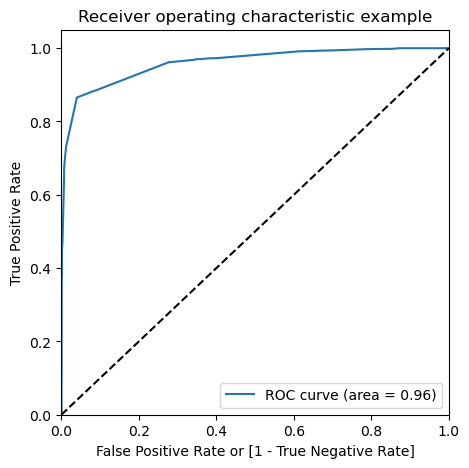

In [144]:
draw_roc(y_train_pred_final.Converted, y_train_pred_final.Converted_prob)

In [145]:
#The ROC Curve should be a value close to 1. We are getting a good value of 0.97 indicating a good predictive model.

In [ ]:
#Finding Optimal Cutoff Point

In [146]:
#Above we had chosen an arbitrary cut-off value of 0.5. We need to determine the best cut-off value and the below section deals with that

In [147]:
# Let's create columns with different probability cutoffs 
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Converted_prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,1,0.073359,9196,0,1,0,0,0,0,0,0,0,0,0
1,0,0.073359,4696,0,1,0,0,0,0,0,0,0,0,0
2,0,0.694909,3274,1,1,1,1,1,1,1,1,0,0,0
3,0,0.008013,2164,0,1,0,0,0,0,0,0,0,0,0
4,1,0.968850,1667,1,1,1,1,1,1,1,1,1,1,1


In [148]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive 
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.380565  1.000000  0.000000
0.1   0.1  0.812191  0.961006  0.720762
0.2   0.2  0.814106  0.961006  0.723854
0.3   0.3  0.923408  0.862893  0.960587
0.4   0.4  0.923408  0.862474  0.960845
0.5   0.5  0.923089  0.861635  0.960845
0.6   0.6  0.923089  0.861635  0.960845
0.7   0.7  0.890219  0.731237  0.987893
0.8   0.8  0.890219  0.731237  0.987893
0.9   0.9  0.871390  0.674214  0.992530


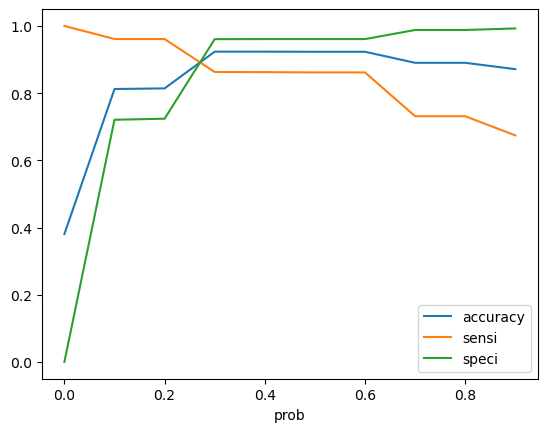

In [149]:
# Let's plot accuracy sensitivity and specificity for various probabilities.
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [150]:
# From the curve above, 0.3 is the optimum point to take it as a cutoff probability.

y_train_pred_final['final_Predicted'] = y_train_pred_final.Converted_prob.map( lambda x: 1 if x > 0.3 else 0)

y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_Predicted
0,1,0.073359,9196,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0.073359,4696,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0.694909,3274,1,1,1,1,1,1,1,1,0,0,0,1
3,0,0.008013,2164,0,1,0,0,0,0,0,0,0,0,0,0
4,1,0.968850,1667,1,1,1,1,1,1,1,1,1,1,1,1


In [151]:
y_train_pred_final['Lead_Score'] = y_train_pred_final.Converted_prob.map( lambda x: round(x*100))

y_train_pred_final[['Converted','Converted_prob','Prospect ID','final_Predicted','Lead_Score']].head()

,Converted,Converted_prob,Prospect ID,final_Predicted,Lead_Score
0,1,0.073359,9196,0,7
1,0,0.073359,4696,0,7
2,0,0.694909,3274,1,69
3,0,0.008013,2164,0,1
4,1,0.968850,1667,1,97


In [152]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_Predicted)

0.9234083293441838

In [153]:
confusion2 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_Predicted )
confusion2

array([[3729,  153],
       [ 327, 2058]], dtype=int64)

In [154]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [155]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

0.8628930817610063

In [156]:
#Observation:
#So as we can see above the model seems to be performing well. The ROC curve has a value of 0.97, which is very good

In [157]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert
print(FP/ float(TN+FP))

0.03941267387944358


In [160]:
# Positive predictive value 
print (TP / float(TP+FP))

0.9308005427408412


In [161]:
# Negative predictive value
print (TN / float(TN+ FN))

0.9193786982248521


In [162]:
#Looking at the confusion matrix again

confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_Predicted )
confusion

array([[3729,  153],
       [ 327, 2058]], dtype=int64)

In [163]:
# Precision
TP / TP + FP

confusion[1,1]/(confusion[0,1]+confusion[1,1])

0.9308005427408412

In [164]:
# Recall
TP / TP + FN

confusion[1,1]/(confusion[1,0]+confusion[1,1])

0.8628930817610063

In [165]:
from sklearn.metrics import precision_score, recall_score

In [166]:
precision_score(y_train_pred_final.Converted , y_train_pred_final.final_Predicted)

0.9308005427408412

In [167]:
recall_score(y_train_pred_final.Converted, y_train_pred_final.final_Predicted)

0.8628930817610063

In [168]:
from sklearn.metrics import precision_recall_curve

In [169]:
y_train_pred_final.Converted, y_train_pred_final.final_Predicted
p, r, thresholds = precision_recall_curve(y_train_pred_final.Converted, y_train_pred_final.Converted_prob)

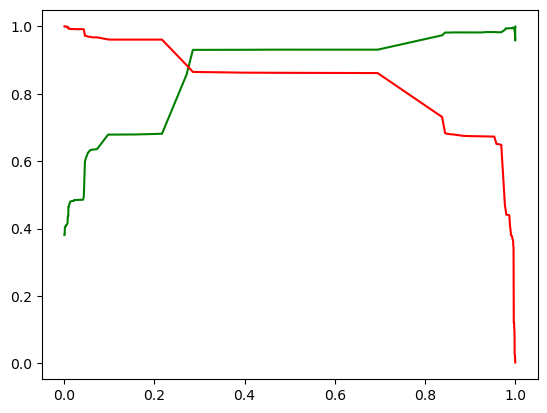

In [170]:
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")
plt.show()

In [171]:
#scaling test set

num_cols=X_test.select_dtypes(include=['float64', 'int64']).columns

X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

X_test.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
7681,0.575687,-0.311318,0.092860,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
984,-0.090676,-0.550262,0.356568,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
8135,-0.423857,0.812462,-0.170849,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
6915,0.242505,-0.628665,-0.170849,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2712,-0.090676,-0.421456,0.356568,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [172]:
X_test = X_test[col]
X_test.head()

,Lead Origin_Lead Add Form,Lead Source_Welingak Website,Last Activity_SMS Sent,Tags_Already a student,Tags_Closed by Horizzon,Tags_Interested in other courses,Tags_Lost to EINS,Tags_Not doing further education,Tags_Other,Tags_Ringing,Tags_Will revert after reading the email,Tags_switched off,Last Notable Activity_Email Link Clicked,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
7681,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
984,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0
8135,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
6915,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2712,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [175]:
X_test_sm = sm.add_constant(X_test)
X_test_sm.head()

,const,Lead Origin_Lead Add Form,Lead Source_Welingak Website,Last Activity_SMS Sent,Tags_Already a student,Tags_Closed by Horizzon,Tags_Interested in other courses,Tags_Lost to EINS,Tags_Not doing further education,Tags_Other,Tags_Ringing,Tags_Will revert after reading the email,Tags_switched off,Last Notable Activity_Email Link Clicked,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation
7681,1.0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
984,1.0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0
8135,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
6915,1.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2712,1.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [176]:
#PREDICTIONS ON TEST SET

In [177]:
y_test_pred = res.predict(X_test_sm)

In [178]:
y_test_pred[:10]

7681    0.073359
984     0.014658
8135    0.694909
6915    0.009544
2712    0.968850
244     0.001597
4698    0.217068
8287    0.044005
6791    0.968850
8970    0.008013
dtype: float64

In [179]:
# Converting y_pred to a dataframe which is an array
y_pred_1 = pd.DataFrame(y_test_pred)

In [180]:
# Let's see the head
y_pred_1.head()

,0
7681,0.073359
984,0.014658
8135,0.694909
6915,0.009544
2712,0.968850


In [182]:
# Converting y_test to dataframe
y_test_df = pd.DataFrame(y_test)

In [183]:
# Putting CustID to index
y_test_df['Prospect ID'] = y_test_df.index

In [184]:
# Removing index for both dataframes to append them side by side 
y_pred_1.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)

In [185]:
# Appending y_test_df and y_pred_1
y_pred_final = pd.concat([y_test_df, y_pred_1],axis=1)

In [186]:
y_pred_final.head()

,Converted,Prospect ID,0
0,0,7681,0.073359
1,0,984,0.014658
2,0,8135,0.694909
3,0,6915,0.009544
4,1,2712,0.968850


In [187]:
# Renaming the column 
y_pred_final= y_pred_final.rename(columns={ 0 : 'Converted_prob'})

In [188]:
y_pred_final.head()

,Converted,Prospect ID,Converted_prob
0,0,7681,0.073359
1,0,984,0.014658
2,0,8135,0.694909
3,0,6915,0.009544
4,1,2712,0.968850


In [189]:
# Rearranging the columns
y_pred_final = y_pred_final[['Prospect ID','Converted','Converted_prob']]
y_pred_final['Lead_Score'] = y_pred_final.Converted_prob.map( lambda x: round(x*100))

In [190]:
# Let's see the head of y_pred_final
y_pred_final.head()

,Prospect ID,Converted,Converted_prob,Lead_Score
0,7681,0,0.073359,7
1,984,0,0.014658,1
2,8135,0,0.694909,69
3,6915,0,0.009544,1
4,2712,1,0.968850,97


In [191]:
y_pred_final['final_Predicted'] = y_pred_final.Converted_prob.map(lambda x: 1 if x > 0.3 else 0)
y_pred_final.head()

,Prospect ID,Converted,Converted_prob,Lead_Score,final_Predicted
0,7681,0,0.073359,7,0
1,984,0,0.014658,1,0
2,8135,0,0.694909,69,1
3,6915,0,0.009544,1,0
4,2712,1,0.968850,97,1


In [192]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_pred_final.Converted, y_pred_final.final_Predicted)

0.9288905435591959

In [193]:
confusion2 = metrics.confusion_matrix(y_pred_final.Converted, y_pred_final.final_Predicted )
confusion2

array([[1614,   62],
       [ 129,  881]], dtype=int64)

In [194]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [195]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

0.8722772277227723

In [196]:
# Let us calculate specificity
TN / float(TN+FP)

0.9630071599045346

In [197]:
precision_score(y_pred_final.Converted , y_pred_final.final_Predicted)

0.9342523860021209

In [198]:
recall_score(y_pred_final.Converted, y_pred_final.final_Predicted)

0.8722772277227723